In [1]:
import numpy as np

In [2]:
rng = np.random.default_rng(seed=42)
m = 200 # number of instances
x = 2 * rng.random((m,1)) # column vector (values between 0 and 2)
y = 4 + 3 * x + rng.standard_normal((m,1)) #column vecto

In [3]:
from sklearn.linear_model import LinearRegression

In [4]:
lin_reg_model = LinearRegression()
lin_reg_model.fit(x,y)

lin_reg_model.intercept_, lin_reg_model.coef_

(array([3.69084138]), array([[3.32960458]]))

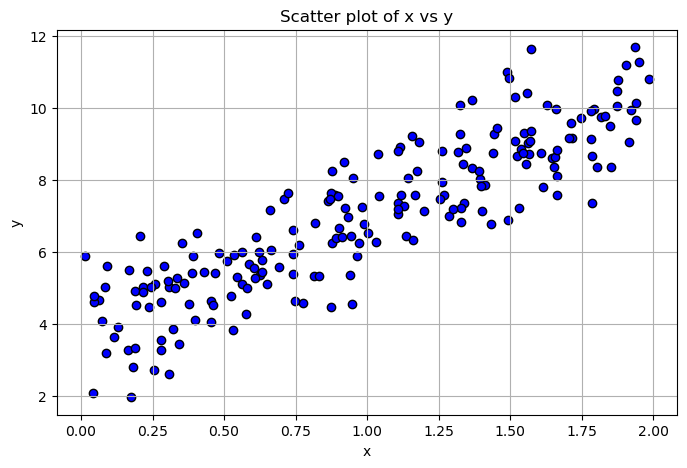

In [5]:
# Scatter plot of x vs y
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', edgecolor='k')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x vs y')
plt.grid(True)
plt.show()

Mean Squared Error: 0.9958


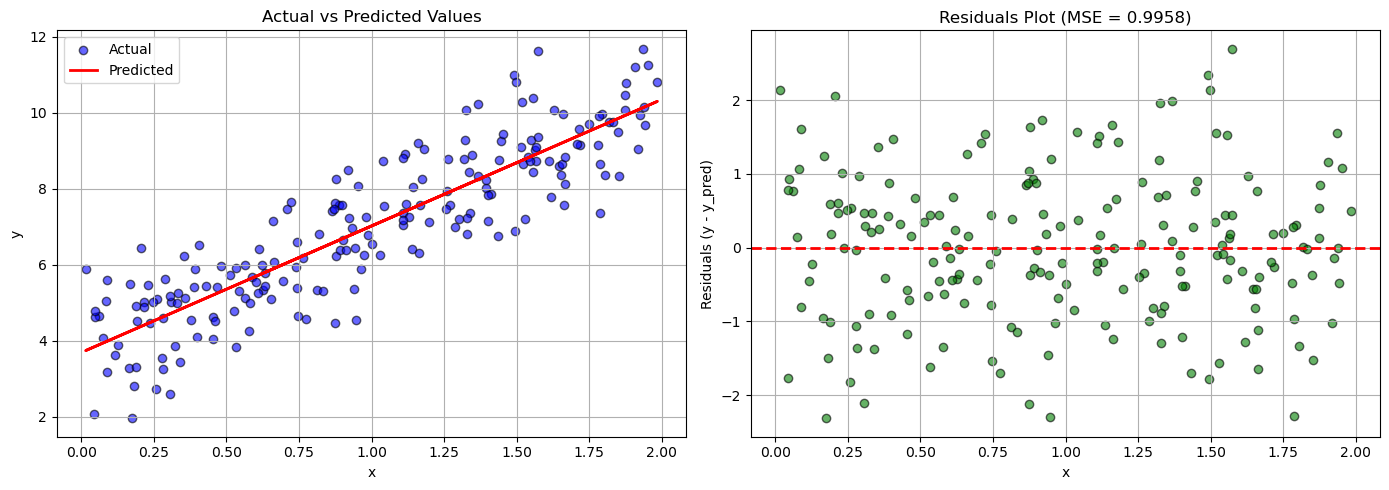

In [6]:
# Cost Function: Mean Squared Error (MSE)
from sklearn.metrics import mean_squared_error

# Make predictions
y_pred = lin_reg_model.predict(x)

# Calculate Mean Squared Error
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

# Plot predicted values vs actual values with cost visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(x, y, color='blue', label='Actual', edgecolor='k', alpha=0.6)
axes[0].plot(x, y_pred, color='red', linewidth=2, label='Predicted')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Actual vs Predicted Values')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Residuals and MSE
residuals = y - y_pred
axes[1].scatter(x, residuals, color='green', edgecolor='k', alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residuals (y - y_pred)')
axes[1].set_title(f'Residuals Plot (MSE = {mse:.4f})')
axes[1].grid(True)

plt.tight_layout()
plt.show()


TypeError: Value after * must be an iterable, not numpy.float64

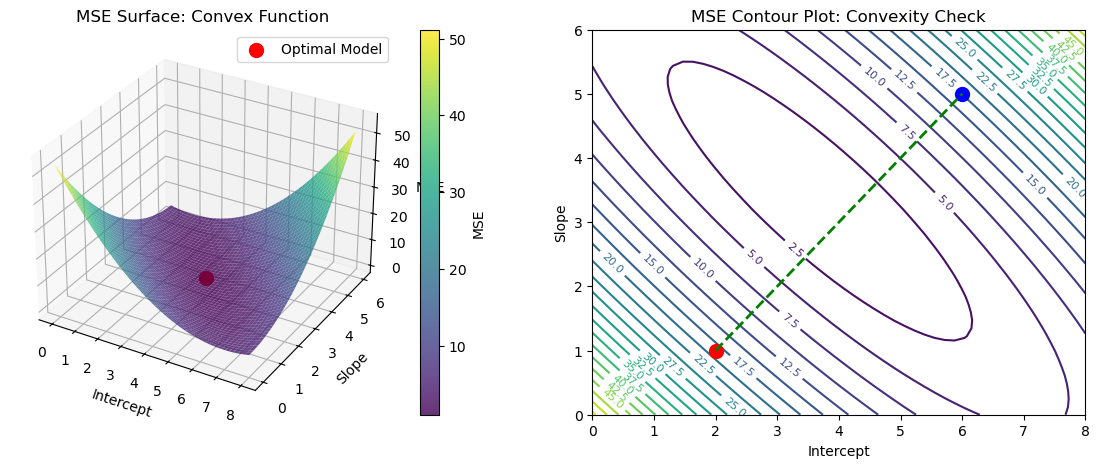

In [7]:
# Visualize MSE as a Convex Function
from mpl_toolkits.mplot3d import Axes3D

# Create a grid of different intercepts and slopes
intercepts = np.linspace(0, 8, 50)
slopes = np.linspace(0, 6, 50)
Intercepts, Slopes = np.meshgrid(intercepts, slopes)

# Calculate MSE for each combination of intercept and slope
MSE_values = np.zeros_like(Intercepts)
for i in range(len(intercepts)):
    for j in range(len(slopes)):
        y_pred_custom = Intercepts[j, i] + Slopes[j, i] * x
        MSE_values[j, i] = np.mean((y - y_pred_custom) ** 2)

# Create 3D surface plot
fig = plt.figure(figsize=(14, 5))

# Plot 1: 3D Surface (MSE as convex function)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(Intercepts, Slopes, MSE_values, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Intercept')
ax1.set_ylabel('Slope')
ax1.set_zlabel('MSE')
ax1.set_title('MSE Surface: Convex Function')
fig.colorbar(surf, ax=ax1, label='MSE')

# Mark the optimal point (where our model converged)
optimal_intercept = lin_reg_model.intercept_[0]
optimal_slope = lin_reg_model.coef_[0][0]
optimal_mse = np.mean((y - lin_reg_model.predict(x)) ** 2)
ax1.scatter([optimal_intercept], [optimal_slope], [optimal_mse], 
            color='red', s=100, marker='o', label='Optimal Model')
ax1.legend()

# Plot 2: Contour plot with convexity demonstration
ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contour(Intercepts, Slopes, MSE_values, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('Intercept')
ax2.set_ylabel('Slope')
ax2.set_title('MSE Contour Plot: Convexity Check')

# Pick two random points on the surface
point1 = np.array([2, 1])  # (intercept, slope)
point2 = np.array([6, 5])  # (intercept, slope)

# Get MSE values at these points
mse_p1 = np.mean((y - (point1[0] + point1[1] * x)) ** 2)
mse_p2 = np.mean((y - (point2[0] + point2[1] * x)) ** 2)

# Plot the two points
ax2.plot(*point1, 'ro', markersize=10, label=f'Point 1: MSE={mse_p1:.2f}')
ax2.plot(*point2, 'bo', markersize=10, label=f'Point 2: MSE={mse_p2:.2f}')

# Draw line segment between points and sample midpoint
t_values = np.linspace(0, 1, 50)
line_points = np.array([point1 + t * (point2 - point1) for t in t_values])
line_mse_values = [np.mean((y - (p[0] + p[1] * x)) ** 2) for p in line_points]

ax2.plot(line_points[:, 0], line_points[:, 1], 'g--', linewidth=2, label='Line segment between points')
ax2.plot(*optimal_intercept, *optimal_slope, 'r*', markersize=20, label='Optimal Model')

ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verify convexity: Check if midpoint MSE is below the line connecting the two endpoint MSEs
print(f"\n--- Convexity Verification ---")
print(f"Point 1 (intercept={point1[0]}, slope={point1[1]}): MSE = {mse_p1:.4f}")
print(f"Point 2 (intercept={point2[0]}, slope={point2[1]}): MSE = {mse_p2:.4f}")

# Midpoint on the line segment
midpoint_on_line = (mse_p1 + mse_p2) / 2
midpoint_params = (point1 + point2) / 2
midpoint_actual = np.mean((y - (midpoint_params[0] + midpoint_params[1] * x)) ** 2)

print(f"\nMidpoint parameters: intercept={midpoint_params[0]:.2f}, slope={midpoint_params[1]:.2f}")
print(f"MSE at midpoint (actual): {midpoint_actual:.4f}")
print(f"Average of endpoint MSEs (line value): {midpoint_on_line:.4f}")
print(f"Convex? {midpoint_actual <= midpoint_on_line} (actual MSE ≤ line value)")
